# CP8305 Final Project
## Notebook 2 – Data Preprocessing

**Team members:** Christopher Indris; Mojtaba Mohammadi; Mohammad Al Batayeh  
**Date:** 2026-03-09

---

### Instructions
Run with a fresh 3.11 environment (I used a 3.11.11 venv "cp8305fp").
Ensure that you pip install ipykernel to run the notebook.

---

### Objectives
- Remove duplicates and handle missing values.
- Detect and treat outliers.
- Encode categorical variables.
- Engineer new features using domain knowledge.
- Scale numerical features.
- Save the processed dataset for modelling.

## 1. Setup

In [44]:
%pip install --upgrade pip
%pip install ucimlrepo # for loading the dataset
%pip install scikit-learn # for data splitting and function application
%pip install matplotlib # for plotting
%pip install seaborn # for statistical plotting

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [45]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_preprocessing import (
    load_raw_data,
    drop_duplicate_rows,
    handle_missing_values,
    remove_outliers_iqr,
    encode_categoricals,
    save_processed_data,
)
from src.feature_engineering import (
    scale_features,
    add_interaction_term,
    add_log_transform,
    add_binned_column,
)
from src.visualization import plot_missing_values, save_figure

sns.set_theme(style='whitegrid')
%matplotlib inline

## 2. Load Data

In [46]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 
  
# data (as pandas dataframes) 
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features 
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets 
idXy = diabetes_130_us_hospitals_for_years_1999_2008.data.original

/Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


### Mappings for encoded values

In [47]:
def read_multiple_tables_csv(filepath, table_delimiter=',\n'):
    """
    Reads a single CSV file containing multiple tables into a list of DataFrames.
    """
    with open(filepath, "r") as f:
        csv_content = f.read()
    
    # Split the content into a list of strings, one for each table
    csv_tables_list = csv_content.split(table_delimiter)
    
    # Convert each string segment into a DataFrame
    dataframe_list = [pd.read_csv(io.StringIO(table_data)) for table_data in csv_tables_list if table_data.strip()]
    
    return dataframe_list

In [48]:
admission_type_ids, discharge_disposition_ids, admission_source_id = read_multiple_tables_csv('../data/diabetes130/raw/IDS_mapping.csv')

## 3. Remove Duplicates

There are no duplicates to drop.

In [49]:
int(X.duplicated().sum()), int(idXy.duplicated().sum())

(0, 0)

## 4. Missing Values

NOTE: since only about 4% of the data is known for weight (see 01_data_exploration), perhaps it's safest just to leave weight out? Especially since weight can be correlated with diabetes.

### Ordinal Categorical

- weight
Since weight is ordinal and categorical (weight is numeric, and it was mapped to ranges of 25 lbs.), we could estimate it by taking the mode (a kind of analogue to the mean). \
However, there may be correlations between it and other variables; in particular, age (which is ordinal categorical from a numeric, mapped to ranges of 10 years). Age also has no missing values. Hence, we could try setting for each row where weight is missing the weight equal to the mode of the weight of all rows where the age is the same as that row.

However, some of them like A1Cresult and max_glu_serum, it is unclear what we would fill those values with. Also, we shouldn't need to make them explicitly ordinal; our ML functions will decide on how each of the values correlate with the output (especially since there are only a few different classes for each of A1Cresult and max_glu_serum)

In [50]:
modes = X['weight'].groupby(X['age']).agg(pd.Series.mode).reset_index(drop=False)
modes['weight'] = modes['weight'].apply(lambda x: x if isinstance(x, str) else x[0])
modes

,age,weight
0,[0-10),[0-25)
1,[10-20),[50-75)
2,[20-30),[50-75)
3,[30-40),[75-100)
4,[40-50),[75-100)
5,[50-60),[75-100)
6,[60-70),[75-100)
7,[70-80),[75-100)
8,[80-90),[50-75)
9,[90-100),[50-75)


In [51]:
modes.loc[modes['age'] == '[0-10)', 'weight'].values[0]

'[0-25)'

In [52]:
# calculate which columns have missing values; we will take the union of those listed in the UCI metadata and those calculated here, so that we don't miss any

# computed directly
mvs = idXy.isna().sum().reset_index(name='missing_values')
mvs = mvs[mvs['missing_values'] > 0]['index'].tolist()

# using metadata
mvs_meta = diabetes_130_us_hospitals_for_years_1999_2008.variables[diabetes_130_us_hospitals_for_years_1999_2008.variables.missing_values == 'yes'].name.tolist()

columns_with_missing_values = list(set(mvs).union(set(mvs_meta)))
columns_with_missing_values

['diag_2',
 'race',
 'A1Cresult',
 'diag_1',
 'max_glu_serum',
 'payer_code',
 'weight',
 'diag_3',
 'medical_specialty']

In [53]:
idXy[columns_with_missing_values].isna().sum()

diag_2                 358
race                  2273
A1Cresult            84748
diag_1                  21
max_glu_serum        96420
payer_code           40256
weight               98569
diag_3                1423
medical_specialty    49949
dtype: int64

In [54]:
# nearly all are missing
idXy['weight'].value_counts(dropna=False)

weight
NaN          98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

In [55]:
# the first 5 rows all have missing weight
idXy[['encounter_id', 'patient_nbr', 'weight', 'age']].head()

,encounter_id,patient_nbr,weight,age
0,2278392,8222157,NaN,[0-10)
1,149190,55629189,NaN,[10-20)
2,64410,86047875,NaN,[20-30)
3,500364,82442376,NaN,[30-40)
4,16680,42519267,NaN,[40-50)


In [56]:
def replace_missing_values(df, columns, replace_with):
    if isinstance(columns, tuple):
        columns, helper_columns = columns
    if replace_with == 'mode':
        for col in columns:
            df[col] = df[col].fillna(df[col].mode().values[0], inplace=False)
    elif replace_with == 'mode_based_on_helper_column':
        for col in columns:
            modes = df[col].groupby(df[helper_columns[0]]).agg(pd.Series.mode).reset_index(drop=False)
            modes[col] = modes[col].apply(lambda x: x if isinstance(x, str) else x[0])
            df[col] = df.apply(lambda row: modes.loc[modes[helper_columns[0]] == row[helper_columns[0]], col].values[0] if pd.isna(row[col]) else row[col], axis=1)
    return df

In [57]:
idXy = replace_missing_values(idXy, (['weight'], ['age']), 'mode_based_on_helper_column')
X = replace_missing_values(X, (['weight'], ['age']), 'mode_based_on_helper_column')

In [58]:
idXy['weight'].value_counts(dropna=False)

weight
[75-100)     78129
[50-75)      22517
[100-125)      625
[0-25)         204
[125-150)      145
[25-50)         97
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

In [59]:
# the weight have been fixed according to our mapping
idXy[['encounter_id', 'patient_nbr', 'weight', 'age']].head()

,encounter_id,patient_nbr,weight,age
0,2278392,8222157,[0-25),[0-10)
1,149190,55629189,[50-75),[10-20)
2,64410,86047875,[50-75),[20-30)
3,500364,82442376,[75-100),[30-40)
4,16680,42519267,[75-100),[40-50)


In [60]:
columns_with_missing_values.remove('weight')

### Nominal Categorical

These are categorical values where we cannot estimate the missing value, so we can simply say "NA".

In [61]:
idXy[columns_with_missing_values].info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   diag_2             101408 non-null  str  
 1   race               99493 non-null   str  
 2   A1Cresult          17018 non-null   str  
 3   diag_1             101745 non-null  str  
 4   max_glu_serum      5346 non-null    str  
 5   payer_code         61510 non-null   str  
 6   diag_3             100343 non-null  str  
 7   medical_specialty  51817 non-null   str  
dtypes: str(8)
memory usage: 6.2 MB


In [62]:
diabetes_130_us_hospitals_for_years_1999_2008.variables[diabetes_130_us_hospitals_for_years_1999_2008.variables.name.isin(columns_with_missing_values)].values

array([['race', 'Feature', 'Categorical', 'Race',
        'Values: Caucasian, Asian, African American, Hispanic, and other',
        None, 'yes'],
       ['payer_code', 'Feature', 'Categorical', nan,
        'Integer identifier corresponding to 23 distinct values, for example, Blue Cross/Blue Shield, Medicare, and self-pay',
        None, 'yes'],
       ['medical_specialty', 'Feature', 'Categorical', nan,
        'Integer identifier of a specialty of the admitting physician, corresponding to 84 distinct values, for example, cardiology, internal medicine, family/general practice, and surgeon',
        None, 'yes'],
       ['diag_1', 'Feature', 'Categorical', nan,
        'The primary diagnosis (coded as first three digits of ICD9); 848 distinct values',
        None, 'yes'],
       ['diag_2', 'Feature', 'Categorical', nan,
        'Secondary diagnosis (coded as first three digits of ICD9); 923 distinct values',
        None, 'yes'],
       ['diag_3', 'Feature', 'Categorical', nan,
     

#### Race

In [63]:
idXy['race'].value_counts(dropna=False)

race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [64]:
# for column 'race' of idXy, replace nan with string "NA"
idXy['race'] = idXy['race'].fillna('NA')
# for column 'race' of X, replace nan with string "NA"
X['race'] = X['race'].fillna('NA')
idXy['race'].value_counts(dropna=False)


race
Caucasian          76099
AfricanAmerican    19210
NA                  2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [65]:
columns_with_missing_values.remove('race')

#### Payer Code

In [66]:
idXy['payer_code'].value_counts(dropna=False)

payer_code
NaN    40256
MC     32439
HM      6274
SP      5007
BC      4655
MD      3532
CP      2533
UN      2448
CM      1937
OG      1033
PO       592
DM       549
CH       146
WC       135
OT        95
MP        79
SI        55
FR         1
Name: count, dtype: int64

In [67]:
# for column 'payer_code' of idXy, replace nan with string "NA"
idXy['payer_code'] = idXy['payer_code'].fillna('NA')
# for column 'payer_code' of X, replace nan with string "NA"
X['payer_code'] = X['payer_code'].fillna('NA')
idXy['payer_code'].value_counts(dropna=False)

payer_code
NA    40256
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532
CP     2533
UN     2448
CM     1937
OG     1033
PO      592
DM      549
CH      146
WC      135
OT       95
MP       79
SI       55
FR        1
Name: count, dtype: int64

In [68]:
columns_with_missing_values.remove('payer_code')

#### Medical Specialty

In [69]:
idXy['medical_specialty'].value_counts(dropna=False)

medical_specialty
NaN                       49949
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5352
                          ...  
Dermatology                   1
SportsMedicine                1
Speech                        1
Perinatology                  1
Neurophysiology               1
Name: count, Length: 73, dtype: int64

In [70]:
# for column 'medical_specialty' of idXy, replace nan with string "NA"
idXy['medical_specialty'] = idXy['medical_specialty'].fillna('NA')
# for column 'medical_specialty' of X, replace nan with string "NA"
X['medical_specialty'] = X['medical_specialty'].fillna('NA')
idXy['medical_specialty'].value_counts(dropna=False)

medical_specialty
NA                        49949
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5352
                          ...  
Dermatology                   1
SportsMedicine                1
Speech                        1
Perinatology                  1
Neurophysiology               1
Name: count, Length: 73, dtype: int64

#### Diagnoses (1, 2, 3)

In [71]:
columns_with_missing_values.remove('medical_specialty')

In [72]:
len(idXy[idXy['diag_1'].isna()]), len(idXy[idXy['diag_2'].isna()]), len(idXy[idXy['diag_3'].isna()])

(21, 358, 1423)

In [73]:
idXy['diag_1'] = idXy['diag_1'].fillna('NA')
X['diag_1'] = X['diag_1'].fillna('NA')
idXy['diag_2'] = idXy['diag_2'].fillna('NA')
X['diag_2'] = X['diag_2'].fillna('NA')
idXy['diag_3'] = idXy['diag_3'].fillna('NA')
X['diag_3'] = X['diag_3'].fillna('NA')

columns_with_missing_values.remove('diag_1')
columns_with_missing_values.remove('diag_2')
columns_with_missing_values.remove('diag_3')


In [74]:
len(idXy[idXy['diag_1'].isna()]), len(idXy[idXy['diag_2'].isna()]), len(idXy[idXy['diag_3'].isna()])

(0, 0, 0)

In [75]:
columns_with_missing_values

['A1Cresult', 'max_glu_serum']

#### max_glu_serum

In [76]:
idXy['max_glu_serum'].value_counts(dropna=False)

max_glu_serum
NaN     96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64

In [77]:
# for column 'max_glu_serum' of idXy, replace nan with string "NA"
idXy['max_glu_serum'] = idXy['max_glu_serum'].fillna('NA')
# for column 'max_glu_serum' of X, replace nan with string "NA"
X['max_glu_serum'] = X['max_glu_serum'].fillna('NA')
idXy['max_glu_serum'].value_counts(dropna=False)

max_glu_serum
NA      96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64

In [78]:
columns_with_missing_values.remove('max_glu_serum')

### A1Cresult

In [79]:
idXy['A1Cresult'].value_counts(dropna=False)

A1Cresult
NaN     84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

In [80]:
# for column 'A1Cresult' of idXy, replace nan with string "NA"
idXy['A1Cresult'] = idXy['A1Cresult'].fillna('NA')
# for column 'A1Cresult' of X, replace nan with string "NA"
X['A1Cresult'] = X['A1Cresult'].fillna('NA')
idXy['max_glu_serum'].value_counts(dropna=False)

max_glu_serum
NA      96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64

In [81]:
columns_with_missing_values.remove('A1Cresult')

## 4. Modifying Data Types

In some cases, even though the data is integer (numerical ordinal), it should be treated as categorical. Examples:

- admission_type_id
- discharge_disposition_id
- admission_source_id

In [82]:
idXy.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [83]:
# convert the datatype of columns 'admission_type_id', 'discharge_disposition_id', 'admission_source_id' to categorical
idXy['admission_type_id'] = idXy['admission_type_id'].astype('category')
idXy['discharge_disposition_id'] = idXy['discharge_disposition_id'].astype('category')
idXy['admission_source_id'] = idXy['admission_source_id'].astype('category')

X['admission_type_id'] = X['admission_type_id'].astype('category')
X['discharge_disposition_id'] = X['discharge_disposition_id'].astype('category')
X['admission_source_id'] = X['admission_source_id'].astype('category')

idXy.info()


<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   encounter_id              101766 non-null  int64   
 1   patient_nbr               101766 non-null  int64   
 2   race                      101766 non-null  str     
 3   gender                    101766 non-null  str     
 4   age                       101766 non-null  str     
 5   weight                    101766 non-null  str     
 6   admission_type_id         101766 non-null  category
 7   discharge_disposition_id  101766 non-null  category
 8   admission_source_id       101766 non-null  category
 9   time_in_hospital          101766 non-null  int64   
 10  payer_code                101766 non-null  str     
 11  medical_specialty         101766 non-null  str     
 12  num_lab_procedures        101766 non-null  int64   
 13  num_procedures            101766 non-nul

In [84]:
# Convert all string-type columns in idXy and X to category dtype
string_columns_idXy = idXy.select_dtypes(include=['object']).columns
for col in string_columns_idXy:
    idXy[col] = idXy[col].astype('category')
    if col in X.columns:
        X[col] = X[col].astype('category')

/var/folders/12/c9d9l3_x50qgympys7czmn0m0000gn/T/ipykernel_71363/1178708622.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_columns_idXy = idXy.select_dtypes(include=['object']).columns


In [85]:
idXy.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   encounter_id              101766 non-null  int64   
 1   patient_nbr               101766 non-null  int64   
 2   race                      101766 non-null  category
 3   gender                    101766 non-null  category
 4   age                       101766 non-null  category
 5   weight                    101766 non-null  category
 6   admission_type_id         101766 non-null  category
 7   discharge_disposition_id  101766 non-null  category
 8   admission_source_id       101766 non-null  category
 9   time_in_hospital          101766 non-null  int64   
 10  payer_code                101766 non-null  category
 11  medical_specialty         101766 non-null  category
 12  num_lab_procedures        101766 non-null  int64   
 13  num_procedures            101766 non-nul

## 5. Outlier Treatment and Numeric Attribute Normalization

### Finding Outliers

In [ ]:
# find the columns which are numeric (type int64) and not 'encounter_id' or 'patient_nbr'
numerical_nonID_columns = idXy.select_dtypes(include=['int64']).columns.drop('encounter_id').drop('patient_nbr')
numerical_nonID_columns


Index(['time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses'],
      dtype='str')

In [89]:
idXy[numerical_nonID_columns].describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.422607,1.933600,1.0,6.0,8.0,9.0,16.0


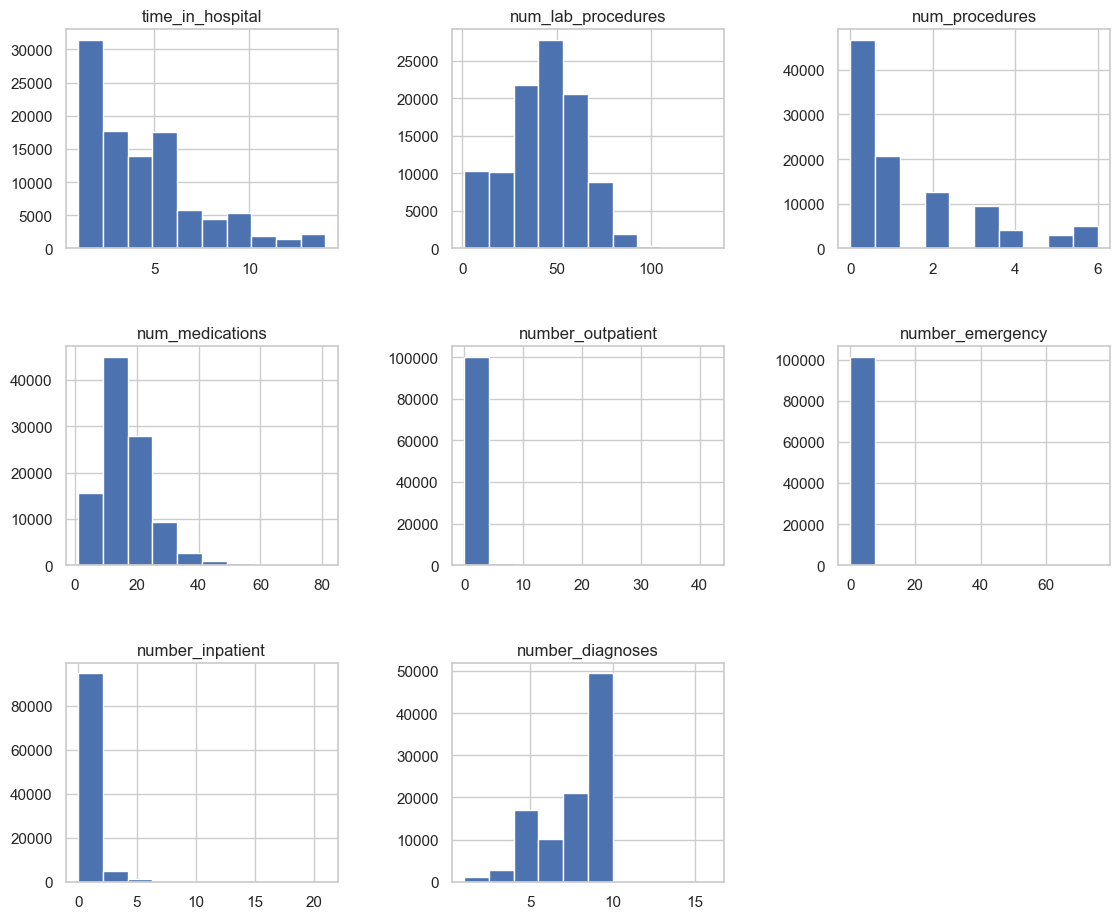

In [92]:
idXy[numerical_nonID_columns].hist(figsize=(12, 10), layout=(3, 3), sharex=False, sharey=False)
plt.tight_layout(pad=3.0)

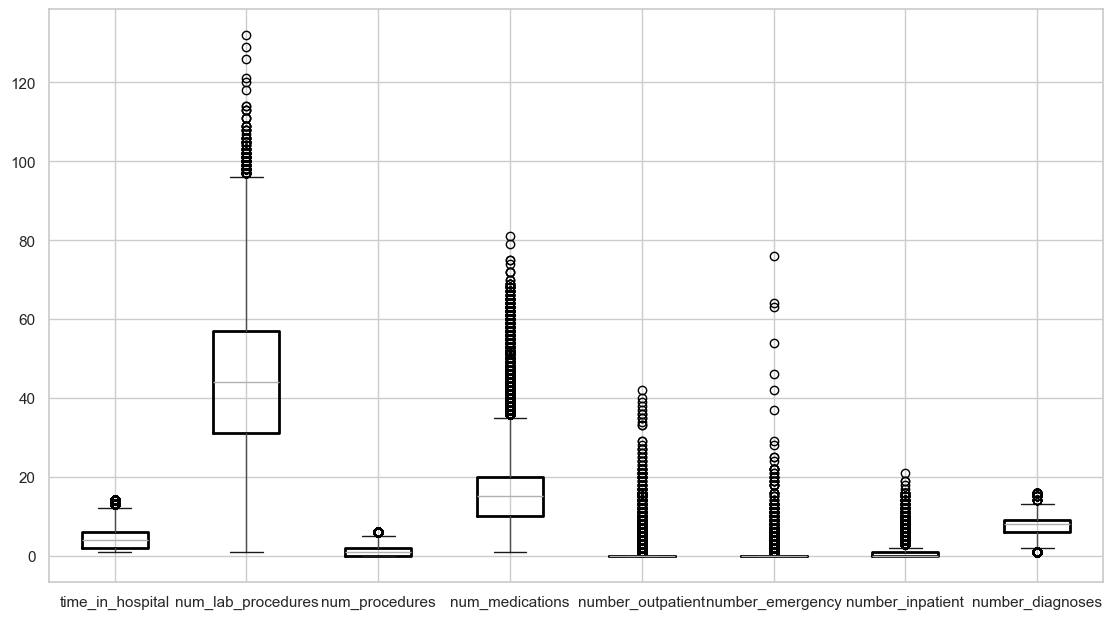

In [98]:
idXy[numerical_nonID_columns].boxplot(figsize=(12, 7), boxprops=dict(lw=2))
plt.tight_layout(pad=3.0)

In [101]:
# Calculate the number of outliers per column based on the boxplot rule (values < Q1-1.5*IQR or > Q3+1.5*IQR)
outlier_counts = []
total_rows = idXy.shape[0]
for col in numerical_nonID_columns:
    q1 = idXy[col].quantile(0.25)
    q3 = idXy[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = idXy[(idXy[col] < lower) | (idXy[col] > upper)]
    count = outliers.shape[0]
    percent = (count / total_rows) * 100 if total_rows > 0 else 0
    outlier_counts.append({'column': col, 'outlier_count': count, 'outlier_percent': percent})

outlier_counts_df = pd.DataFrame(outlier_counts)
print("Number and percentage of outliers per numeric column according to boxplot method (as DataFrame):")
display(outlier_counts_df)

Number and percentage of outliers per numeric column according to boxplot method (as DataFrame):


,column,outlier_count,outlier_percent
0,time_in_hospital,2252,2.212920
1,num_lab_procedures,143,0.140518
2,num_procedures,4954,4.868031
3,num_medications,2557,2.512627
4,number_outpatient,16739,16.448519
5,number_emergency,11383,11.185465
6,number_inpatient,7049,6.926675
7,number_diagnoses,281,0.276124


### Adjusting the Numerical Scales

In [ ]:
# TODO: List numeric columns where outlier removal is appropriate.
outlier_columns = []  # e.g. ['price', 'quantity']

if outlier_columns:
    df = remove_outliers_iqr(df, outlier_columns)

print(f'Shape after outlier removal: {df.shape}')

## 6. Feature Engineering

In [ ]:
# TODO: Add domain-specific derived features.
# Examples – uncomment and adapt as needed:

# df = add_log_transform(df, columns=['price'])
# df = add_interaction_term(df, 'col_a', 'col_b', name='col_a_x_col_b')
# df = add_binned_column(df, 'age', bins=4)

print('Feature engineering complete.')
print(f'Columns after engineering: {list(df.columns)}')

## 7. Encode Categorical Variables

In [ ]:
# TODO: List categorical columns to one-hot encode.
categorical_columns = []  # e.g. ['region', 'category']

if categorical_columns:
    df = encode_categoricals(df, categorical_columns)

print(f'Shape after encoding: {df.shape}')

## 8. Scale Numeric Features

In [ ]:
# TODO: Decide which numeric columns to scale and choose method.
# Note: exclude the target column from scaling.
target_column = 'target'  # <-- Change this
scale_cols = [
    c for c in df.select_dtypes(include=np.number).columns
    if c != target_column
]

# Comment out the lines below if you prefer to scale inside the modeling pipeline.
# df, scaler = scale_features(df, scale_cols, method='standard')

print('Scaling step ready – uncomment the line above to apply.')

## 9. Final Check & Save

In [ ]:
print(f'Final shape  : {df.shape}')
print(f'Dtypes:\n{df.dtypes.value_counts()}')
print(f'Missing total: {df.isnull().sum().sum()}')
df.head()

In [ ]:
save_processed_data(df, 'processed_dataset.csv')
print('Preprocessing complete. Proceed to Notebook 3 – Modeling.')